# Model extensions: APBS-free quick run

**11 configurations, seed 7, the existing 10% subset.** Compare the original base GAT, full-feature GAT, interface-only pooling, ESM embeddings, and EGNN encoders with autoencoder or supervised objectives. All predictions come from validation-selected checkpoints.

This is a **single-seed exploratory comparison**, not a measurement of seed robustness. APBS is absent. The full baseline retains Voronoi area/mask and interface-node degree. “Combined” means ESM plus interface pooling. Fixed loss weights replace the adaptive weights used in the earlier full-dataset seed replicates; those older results are not directly paired with this subset experiment.

Figure text and mathematics use LaTeX Computer Modern. CSV tables and PNG/PDF figures are exported beside the notebook, without modifying the downloaded runs.

In [1]:
from pathlib import Path
import json, hashlib, shutil, base64
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML
get_ipython().run_line_magic('matplotlib', 'inline')
ROOT_NAME='model_extensions_10pct_quick_no_apbs'
GATE_DIR=next((p for parent in [Path.cwd(),*Path.cwd().parents] for p in [parent,parent/'gate_run'] if (p/ROOT_NAME/'matrix.json').is_file()),None)
if GATE_DIR is None: raise FileNotFoundError('Set GATE_DIR to the repository gate_run directory')
ROOT=GATE_DIR/ROOT_NAME
OUT=GATE_DIR/'model_extensions_quick_analysis'; OUT.mkdir(exist_ok=True)
if not shutil.which('latex'): raise RuntimeError('LaTeX is required for Computer Modern figure text')
mpl.rcParams.update({'text.usetex':True, 'font.family':'serif', 'font.serif':['Computer Modern Roman'],
 'mathtext.fontset':'cm','axes.spines.top':False,'axes.spines.right':False,'legend.frameon':False,
 'figure.dpi':110,'savefig.dpi':180,'axes.labelsize':11,'axes.titlesize':12})
# Embed the Computer Modern font for notebook prose and table output too.
font=Path(mpl.get_data_path())/'fonts/ttf/cmr10.ttf'
encoded=base64.b64encode(font.read_bytes()).decode()
display(HTML("<style>@font-face{font-family:NotebookCM;src:url(data:font/ttf;base64,"+encoded+")} .text_cell_render,.jp-RenderedHTMLCommon,table.dataframe{font-family:NotebookCM,serif;}</style>"))
MATRIX=json.loads((ROOT/'matrix.json').read_text())
META=json.loads((GATE_DIR/'model_extensions_quick_metadata.json').read_text())
LABELS={'seed_replicate_base':'Original base GAT','baseline':'Full GAT baseline',
 'gat_none_all_esm1':'GAT + ESM','gat_none_interface_esm0':'GAT + interface pooling',
 'gat_none_interface_esm1':'GAT + ESM + interface', 'egnn_ae_baseline':'EGNN autoencoder',
 'egnn_ae_combined':'EGNN autoencoder combined','egnn_supervised_baseline':'EGNN supervised',
 'egnn_supervised_combined':'EGNN supervised combined','gat_supervised_baseline':'GAT supervised',
 'gat_supervised_combined':'GAT supervised combined'}
ORDER=[r['config']['name'] for r in MATRIX['runs']]
COLORS={c:('#333333' if c=='baseline' else '#999999' if c=='seed_replicate_base' else '#d17b32' if c.startswith('egnn') else '#247ba0') for c in ORDER}
def save(fig,name):
 fig.savefig(OUT/f'{name}.pdf',bbox_inches='tight');fig.savefig(OUT/f'{name}.png',bbox_inches='tight');plt.show()
def export(frame,name): frame.to_csv(OUT/f'{name}.csv',index=False)
print('Input:',ROOT);print('Exports:',OUT)

Input: /scratch/PPI-graph_autoencoder/gate_run/model_extensions_10pct_quick_no_apbs
Exports: /scratch/PPI-graph_autoencoder/gate_run/model_extensions_quick_analysis


## Validate completion, configuration, and common test cohort

Cluster paths in the matrix are remapped to local run-folder names. Cohort keys, labels, finite predictions, and checkpoint/CSV hashes are checked. Target split overlap is forbidden. No intersection or silent filtering is used to make incompatible predictions look comparable.

In [2]:
predictions={}; histories={}; rows=[]; reference=None
assert MATRIX['apbs_enabled'] is False and len(ORDER)==11 and len(set(ORDER))==11
splits=json.loads((ROOT/'target_splits.json').read_text())['splits']
sets={k:set(v.get('targets',[Path(p).stem for p in v['paths']])) for k,v in splits.items()}
assert not any(sets[a]&sets[b] for a,b in [('train','val'),('train','test'),('val','test')])
for run in MATRIX['runs']:
 c=run['config']['name'];folder=Path(run['output']).name;directory=ROOT/folder;meta=META[folder]
 for filename,expected in meta['sha256'].items():
  assert hashlib.sha256((directory/filename).read_bytes()).hexdigest()==expected, f'Changed input: {folder}/{filename}'
 f=pd.read_csv(directory/'test_predictions.csv').sort_values(['target_id','graph_name']).reset_index(drop=True)
 h=pd.read_csv(directory/'loss_history.csv')
 assert len(f)>0 and not f.duplicated(['target_id','graph_name']).any()
 assert np.isfinite(f[['true_target','predicted_target']]).all().all() and f.true_target.between(0,1).all()
 identity=f[['target_id','graph_name','true_target']]
 if reference is None: reference=identity
 else: assert reference.equals(identity),f'Cohort mismatch: {c}'
 assert set(f.target_id)==sets['test']
 expected_keys={(t,g) for t,g in MATRIX['cohort_keys'] if t in sets['test']}
 assert set(zip(f.target_id,f.graph_name))==expected_keys
 assert len(h)==meta['args']['epochs'] and h.epoch.is_unique and h.epoch.is_monotonic_increasing
 assert meta['args']['loss_weight_mode']=='fixed' and run['config']['apbs']=='none'
 best=h.loc[h.epoch.eq(meta['best_epoch'])].iloc[0]
 assert np.isclose(best.val_target_mse,meta['best_metric_value'])
 predictions[c]=f;histories[c]=h
 rows.append(dict(config=c,label=LABELS[c],seed=run['seed'],architecture=run['config']['architecture'],
  objective=run['config']['objective'],pooling=run['config']['pooling'],esm=run['config']['esm'],
  epochs=len(h),checkpoint_epoch=meta['best_epoch'],validation_mse=meta['best_metric_value'],
  graphs=len(f),targets=f.target_id.nunique()))
inventory=pd.DataFrame(rows);display(inventory);export(inventory,'inventory')
print(f'Identical test cohort: {len(reference):,} graphs / {reference.target_id.nunique()} targets.')
print('Split target counts:',{k:len(v) for k,v in sets.items()})
print('Preparation attrition:',sum(v['accepted'] for v in MATRIX['cohort'].values()),'accepted,',sum(v['rejected'] for v in MATRIX['cohort'].values()),'rejected.')

,config,label,seed,architecture,objective,pooling,esm,epochs,checkpoint_epoch,validation_mse,graphs,targets
0,seed_replicate_base,Original base GAT,7,gat,ae,all,False,50,5,0.080473,3044,25
1,baseline,Full GAT baseline,7,gat,ae,all,False,50,5,0.076607,3044,25
2,gat_none_all_esm1,GAT + ESM,7,gat,ae,all,True,50,1,0.084982,3044,25
3,gat_none_interface_esm0,GAT + interface pooling,7,gat,ae,interface,False,50,16,0.078713,3044,25
4,gat_none_interface_esm1,GAT + ESM + interface,7,gat,ae,interface,True,50,1,0.092044,3044,25
5,egnn_ae_baseline,EGNN autoencoder,7,egnn,ae,all,False,50,1,0.081213,3044,25
6,egnn_ae_combined,EGNN autoencoder combined,7,egnn,ae,interface,True,50,1,0.087324,3044,25
7,egnn_supervised_baseline,EGNN supervised,7,egnn,supervised,all,False,50,3,0.078265,3044,25
8,egnn_supervised_combined,EGNN supervised combined,7,egnn,supervised,interface,True,50,1,0.132191,3044,25
9,gat_supervised_baseline,GAT supervised,7,gat,supervised,all,False,50,3,0.080727,3044,25


Identical test cohort: 3,044 graphs / 25 targets.
Split target counts: {'train': 90, 'val': 10, 'test': 25}
Preparation attrition: 15086 accepted, 0 rejected.


## Accuracy, ranking, and structure selection

**Macro metrics weight each target equally**; pooled metrics weight each graph equally. Spearman is calculated within targets. Top-1 is the true DockQ of the highest predicted candidate. Top-5/top-10 report the best true DockQ among those candidates, assuming later inspection can identify it. Regret is the gap between the best available structure and top-1. Ties use graph-name ordering. Undefined target correlations are counted explicitly.

The mean DockQ within each target is the expected quality of a uniformly random single selection. It is a reference, not a trained predictor.

,rmse,mae,r2,pearson,macro_mse,macro_spearman,defined_correlations,top1,top5,top10,regret,random,oracle,bias,outside_0_1
config,,,,,,,,,,,,,,,
baseline,0.2491,0.2086,0.3574,0.6047,0.0626,0.6158,25,0.5354,0.7246,0.8128,0.3652,0.3294,0.9006,0.0250,0
gat_none_interface_esm0,0.2524,0.1962,0.3399,0.5952,0.0642,0.5996,25,0.4531,0.7550,0.8546,0.4475,0.3294,0.9006,0.0099,0
gat_none_all_esm1,0.2593,0.2029,0.3034,0.5651,0.0676,0.6474,25,0.4275,0.6855,0.7892,0.4731,0.3294,0.9006,-0.0370,58
gat_supervised_baseline,0.2603,0.2056,0.2981,0.5755,0.0677,0.6208,25,0.4076,0.6361,0.8157,0.4930,0.3294,0.9006,-0.0540,6
egnn_supervised_baseline,0.2600,0.2071,0.2995,0.5542,0.0681,0.6615,25,0.4108,0.6845,0.7748,0.4898,0.3294,0.9006,-0.0138,3
gat_none_interface_esm1,0.2618,0.2006,0.2898,0.5660,0.0692,0.6423,25,0.4206,0.6940,0.7889,0.4800,0.3294,0.9006,-0.0422,136
seed_replicate_base,0.2654,0.2181,0.2703,0.5412,0.0698,0.5872,25,0.4842,0.7016,0.8094,0.4164,0.3294,0.9006,-0.0363,0
egnn_ae_baseline,0.2748,0.2264,0.2175,0.4971,0.0752,0.6381,25,0.4258,0.6966,0.8055,0.4748,0.3294,0.9006,-0.0446,0
gat_supervised_combined,0.2737,0.1875,0.2238,0.6428,0.0766,0.7347,25,0.5604,0.7607,0.8230,0.3402,0.3294,0.9006,-0.1352,134


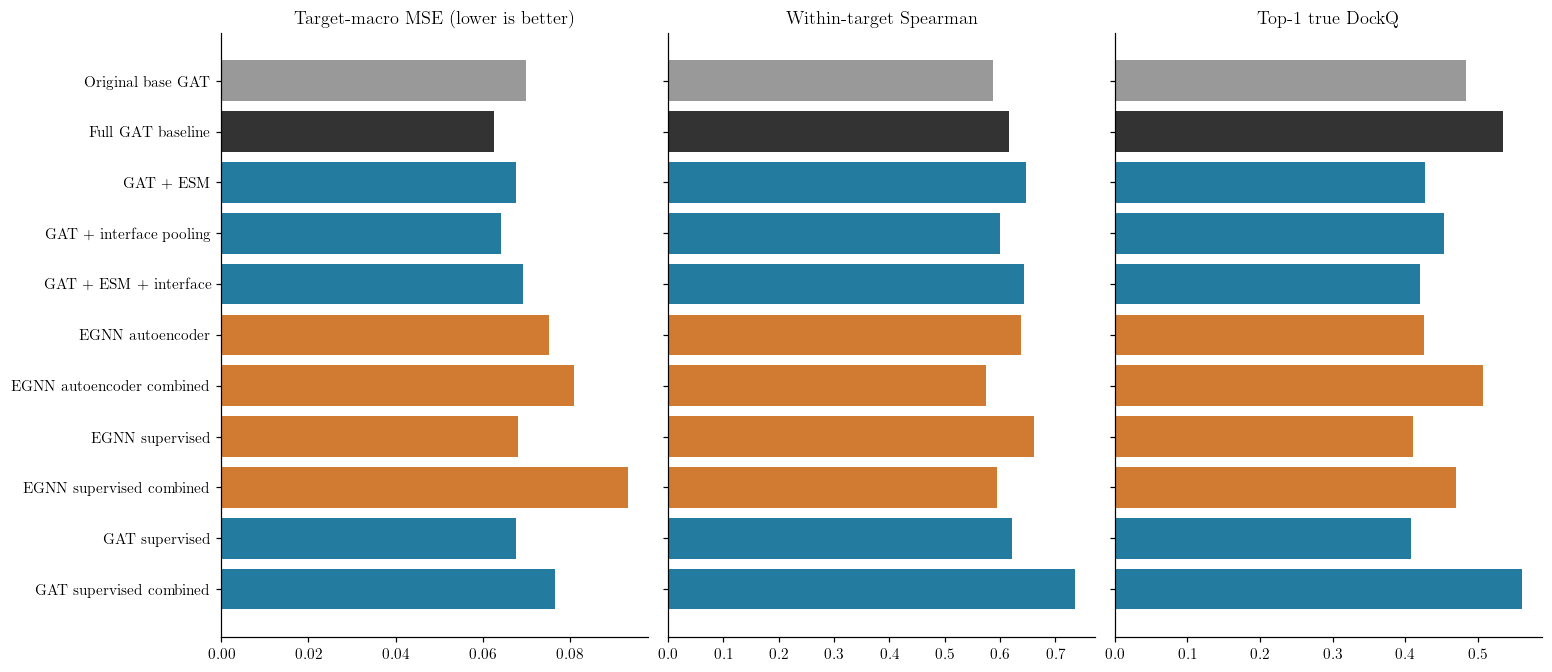

In [3]:
def corr(y,p,rank=False):
 return float((spearmanr if rank else pearsonr)(y,p).statistic) if len(y)>1 and np.std(y)>0 and np.std(p)>0 else np.nan
tr=[];mr=[]
for c,f in predictions.items():
 start=len(tr)
 for t,g in f.groupby('target_id',sort=True):
  y=g.true_target.to_numpy();p=g.predicted_target.to_numpy();order=np.argsort(-p,kind='stable')
  tr.append(dict(config=c,target=t,n=len(g),mse=np.mean((p-y)**2),mae=np.mean(abs(p-y)),
   spearman=corr(y,p,True),bias=np.mean(p-y),top1=y[order[0]],top5=y[order[:5]].max(),
   top10=y[order[:10]].max(),oracle=y.max(),random=y.mean(),regret=y.max()-y[order[0]]))
 target=pd.DataFrame(tr[start:]);y=f.true_target.to_numpy();p=f.predicted_target.to_numpy();mse=np.mean((p-y)**2)
 mr.append(dict(config=c,rmse=np.sqrt(mse),mae=np.mean(abs(p-y)),r2=1-mse/np.var(y),pearson=corr(y,p),
  macro_mse=target.mse.mean(),macro_spearman=target.spearman.mean(),defined_correlations=target.spearman.notna().sum(),
  top1=target.top1.mean(),top5=target.top5.mean(),top10=target.top10.mean(),regret=target.regret.mean(),
  random=target.random.mean(),oracle=target.oracle.mean(),bias=np.mean(p-y),outside_0_1=int(((p<0)|(p>1)).sum())))
metrics=pd.DataFrame(mr).set_index('config'); per_target=pd.DataFrame(tr)
display(metrics.sort_values('macro_mse').round(4));export(metrics.reset_index(),'metrics');export(per_target,'per_target_metrics')
fig,axes=plt.subplots(1,3,figsize=(14,6),sharey=True,constrained_layout=True)
for ax,metric,title in zip(axes,['macro_mse','macro_spearman','top1'],['Target-macro MSE (lower is better)','Within-target Spearman','Top-1 true DockQ']):
 ax.barh(np.arange(len(ORDER)),metrics.loc[ORDER,metric],color=[COLORS[c] for c in ORDER])
 ax.set(yticks=np.arange(len(ORDER)),yticklabels=[LABELS[c] for c in ORDER],title=title)
axes[0].invert_yaxis();save(fig,'metric_overview')

## Paired improvements against both controls

Bootstrap whole targets, preserving model pairing (10,000 draws). Positive improvement means lower target-macro MSE than the selected control. Thin intervals use Bonferroni-adjusted quantiles across the ten comparisons with each control; thick intervals are pointwise 95% intervals. These describe target uncertainty **conditional on this one seed and split**, not seed variance. The two control families are reported separately.

Saved cluster summaries are checked against recomputed metrics before plotting.

,reference,config,improvement,low,high,family_low,family_high,improved_targets
0,baseline,seed_replicate_base,-0.00723,-0.01376,-0.00071,-0.01645,0.00216,9
1,baseline,baseline,0.00000,0.00000,0.00000,0.00000,0.00000,0
2,baseline,gat_none_all_esm1,-0.00502,-0.01405,0.00255,-0.01909,0.00494,13
3,baseline,gat_none_interface_esm0,-0.00165,-0.01116,0.00774,-0.01501,0.01190,12
4,baseline,gat_none_interface_esm1,-0.00658,-0.01884,0.00356,-0.02576,0.00666,13
5,baseline,egnn_ae_baseline,-0.01263,-0.01898,-0.00627,-0.02172,-0.00367,8
6,baseline,egnn_ae_combined,-0.01828,-0.02686,-0.00972,-0.03071,-0.00593,4
7,baseline,egnn_supervised_baseline,-0.00547,-0.01228,0.00118,-0.01580,0.00397,10
8,baseline,egnn_supervised_combined,-0.03066,-0.05181,-0.01086,-0.06183,-0.00343,11
9,baseline,gat_supervised_baseline,-0.00509,-0.01283,0.00214,-0.01666,0.00526,12


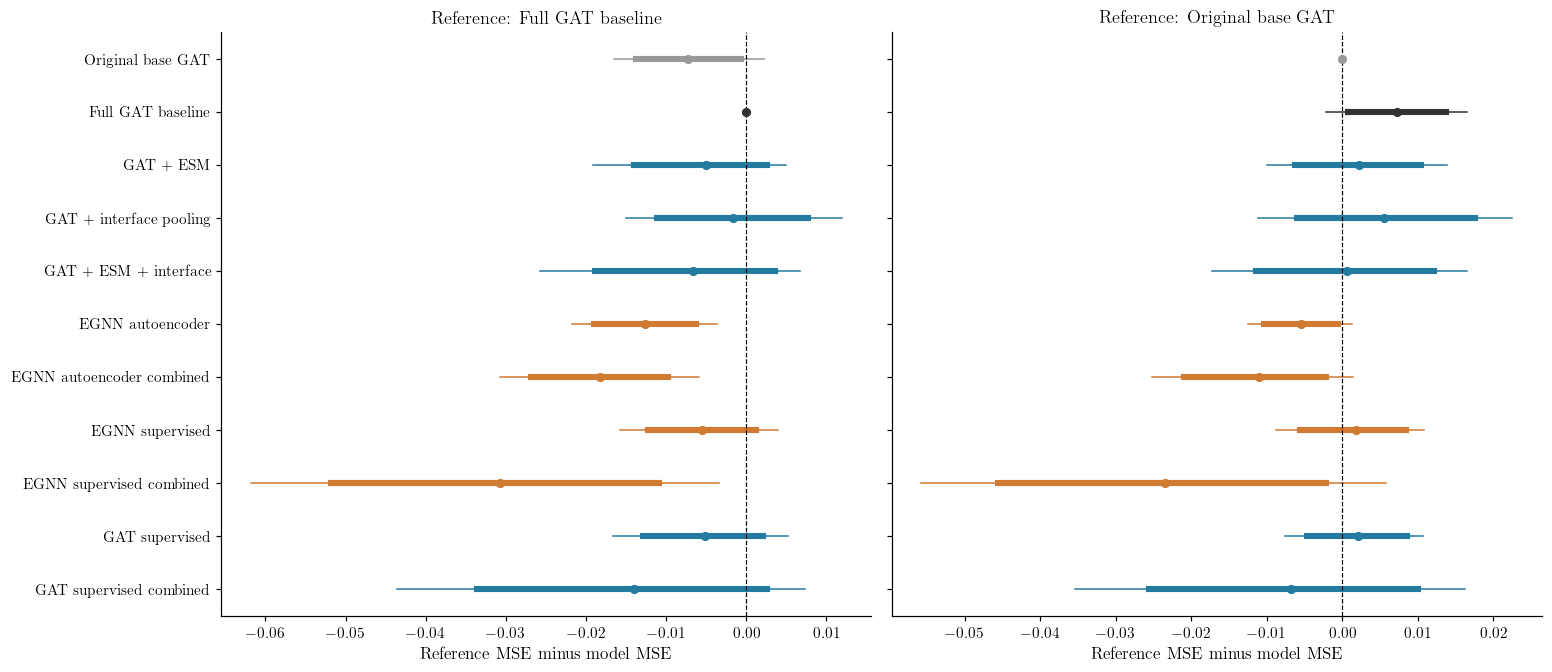

In [4]:
rng=np.random.default_rng(123)
pivot=per_target.pivot(index='target',columns='config',values='mse').sort_index()
ix=rng.integers(len(pivot),size=(10000,len(pivot))); records=[]
for ref in ['baseline','seed_replicate_base']:
 for c in ORDER:
  delta=(pivot[ref]-pivot[c]).to_numpy(); draws=delta[ix].mean(axis=1)
  records.append(dict(reference=ref,config=c,improvement=delta.mean(),low=np.quantile(draws,.025),high=np.quantile(draws,.975),
   family_low=np.quantile(draws,.025/10),family_high=np.quantile(draws,1-.025/10),improved_targets=int((delta>0).sum())))
paired=pd.DataFrame(records);export(paired,'paired_bootstrap')
for directory,ref in [('comparison','baseline'),('comparison_vs_seed_base','seed_replicate_base')]:
 saved=pd.read_csv(ROOT/directory/'comparison.csv').set_index('config')
 for metric in ['macro_mse','macro_spearman']:
  np.testing.assert_allclose(saved.loc[ORDER,metric],metrics.loc[ORDER,metric],rtol=1e-7,atol=1e-9)
display(paired[paired.reference.eq('baseline')].round(5))
fig,axes=plt.subplots(1,2,figsize=(14,6),sharey=True,constrained_layout=True)
for ax,ref in zip(axes,['baseline','seed_replicate_base']):
 d=paired[paired.reference.eq(ref)].set_index('config').loc[ORDER]
 for i,c in enumerate(ORDER):
  r=d.loc[c];ax.plot([r.family_low,r.family_high],[i,i],color=COLORS[c],lw=1)
  ax.plot([r.low,r.high],[i,i],color=COLORS[c],lw=4)
  ax.scatter(r.improvement,i,color=COLORS[c],s=25,zorder=3)
 ax.axvline(0,color='black',ls='--',lw=.8)
 ax.set(yticks=range(len(ORDER)),yticklabels=[LABELS[c] for c in ORDER],title='Reference: '+LABELS[ref],xlabel='Reference MSE minus model MSE')
axes[0].invert_yaxis();save(fig,'paired_mse_intervals')

## Training and validation

The dashed line marks the actual saved checkpoint epoch, verified against its metadata. Raw DockQ MSE is directly comparable across objectives; total losses are not, because supervised runs omit the reconstruction objectives. Test histories are not used for checkpoint selection.

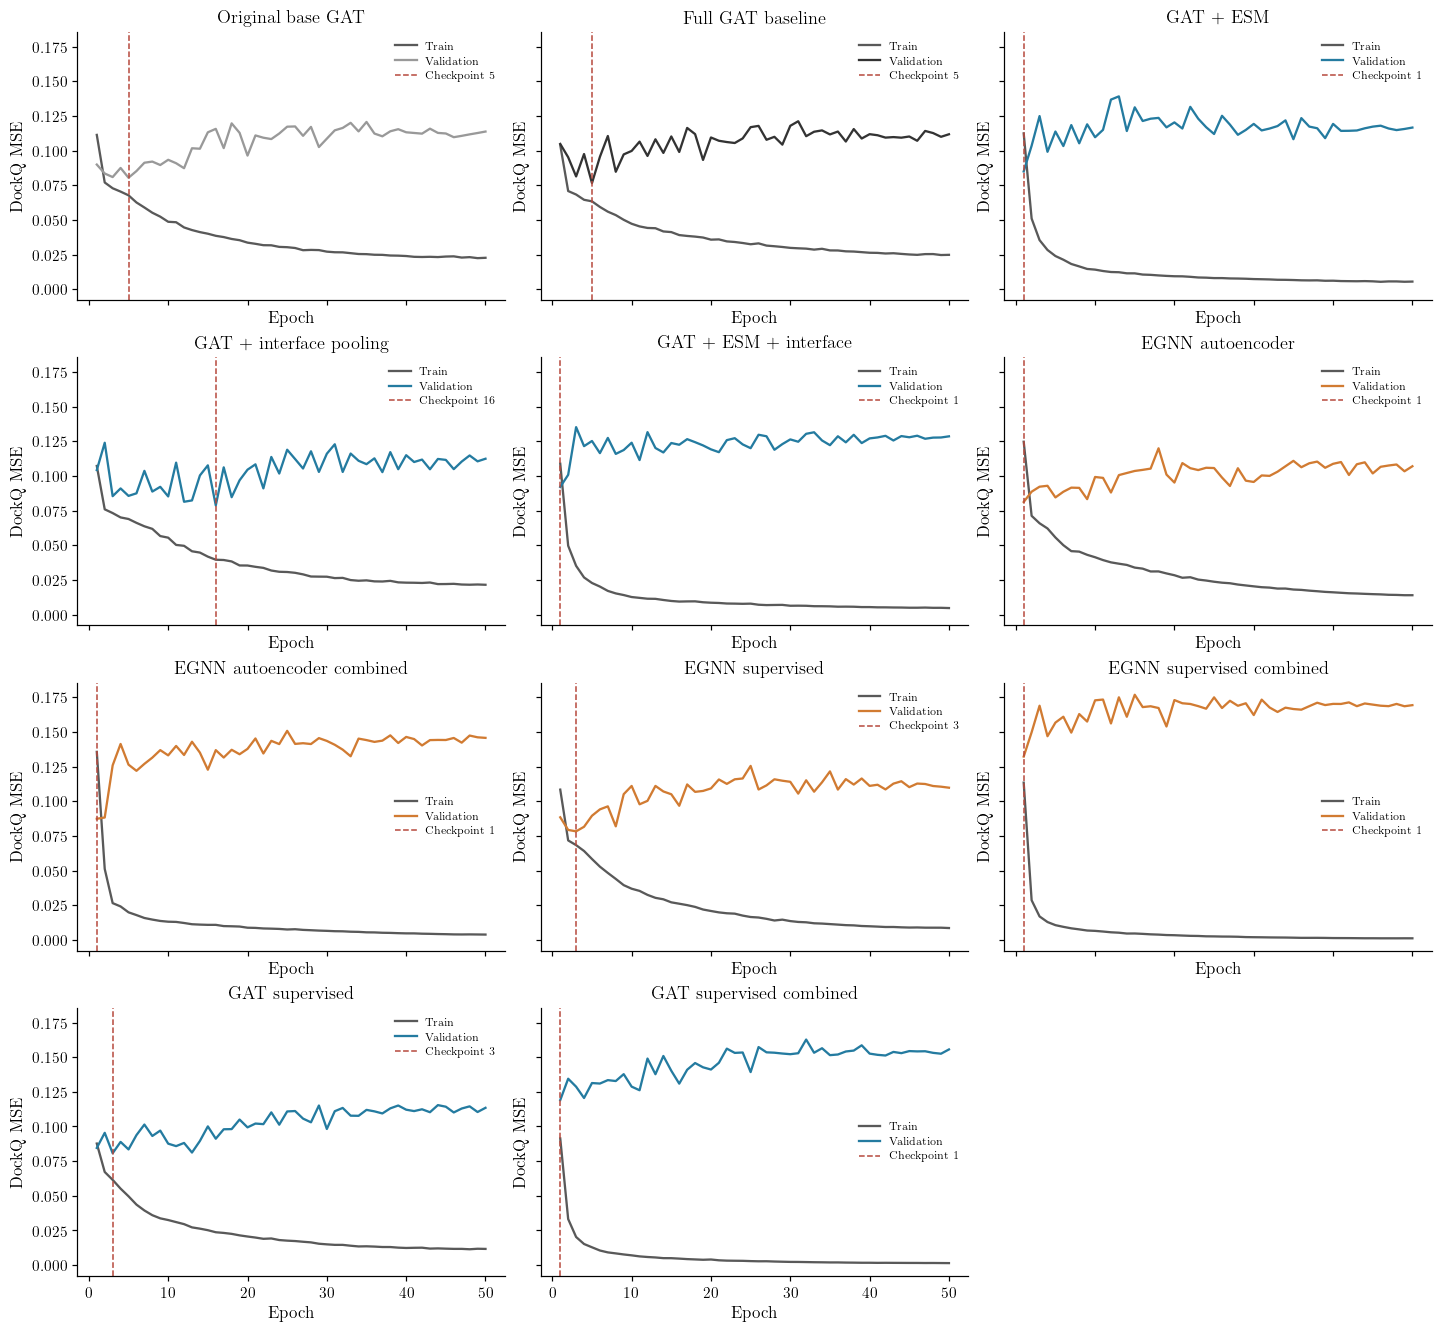

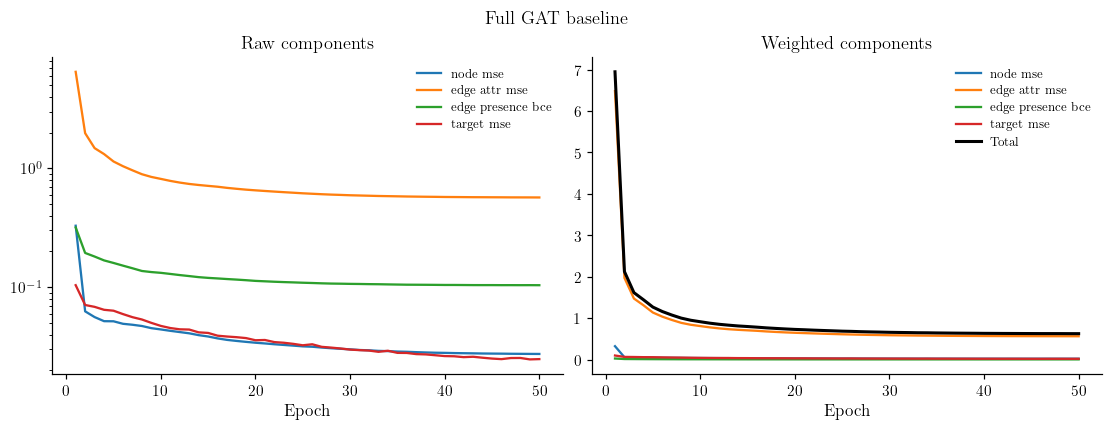

In [5]:
fig,axes=plt.subplots(4,3,figsize=(13,12),sharex=True,sharey=True,constrained_layout=True)
for ax,c in zip(axes.flat,ORDER):
 h=histories[c];epoch=int(inventory.set_index('config').loc[c,'checkpoint_epoch'])
 ax.plot(h.epoch,h.train_target_mse,color='0.35',label='Train')
 ax.plot(h.epoch,h.val_target_mse,color=COLORS[c],label='Validation')
 ax.axvline(epoch,color='#b6493d',ls='--',lw=1,label=f'Checkpoint {epoch}')
 ax.set(title=LABELS[c],xlabel='Epoch',ylabel='DockQ MSE');ax.legend(fontsize=7)
for ax in list(axes.flat)[len(ORDER):]:ax.set_visible(False)
save(fig,'training_validation')
SELECTED_RUN='baseline'
h=histories[SELECTED_RUN]
fig,axes=plt.subplots(1,2,figsize=(10,3.8),constrained_layout=True)
for term in ['node_mse','edge_attr_mse','edge_presence_bce','target_mse']:
 axes[0].plot(h.epoch,h['train_'+term],label=term.replace('_',' '))
 axes[1].plot(h.epoch,h['train_weighted_'+term],label=term.replace('_',' '))
axes[1].plot(h.epoch,h.train_loss,color='black',label='Total',lw=2)
axes[0].set_yscale('log')
for ax,title in zip(axes,['Raw components','Weighted components']):
 ax.set(title=title,xlabel='Epoch');ax.legend(fontsize=8)
fig.suptitle(LABELS[SELECTED_RUN]);save(fig,'loss_components_'+SELECTED_RUN)

## Prediction spread and systematic bias

All panels share axes; dashed lines show perfect prediction. Predictions remain unclipped in every metric. High-quality structures below the diagonal are underpredicted.

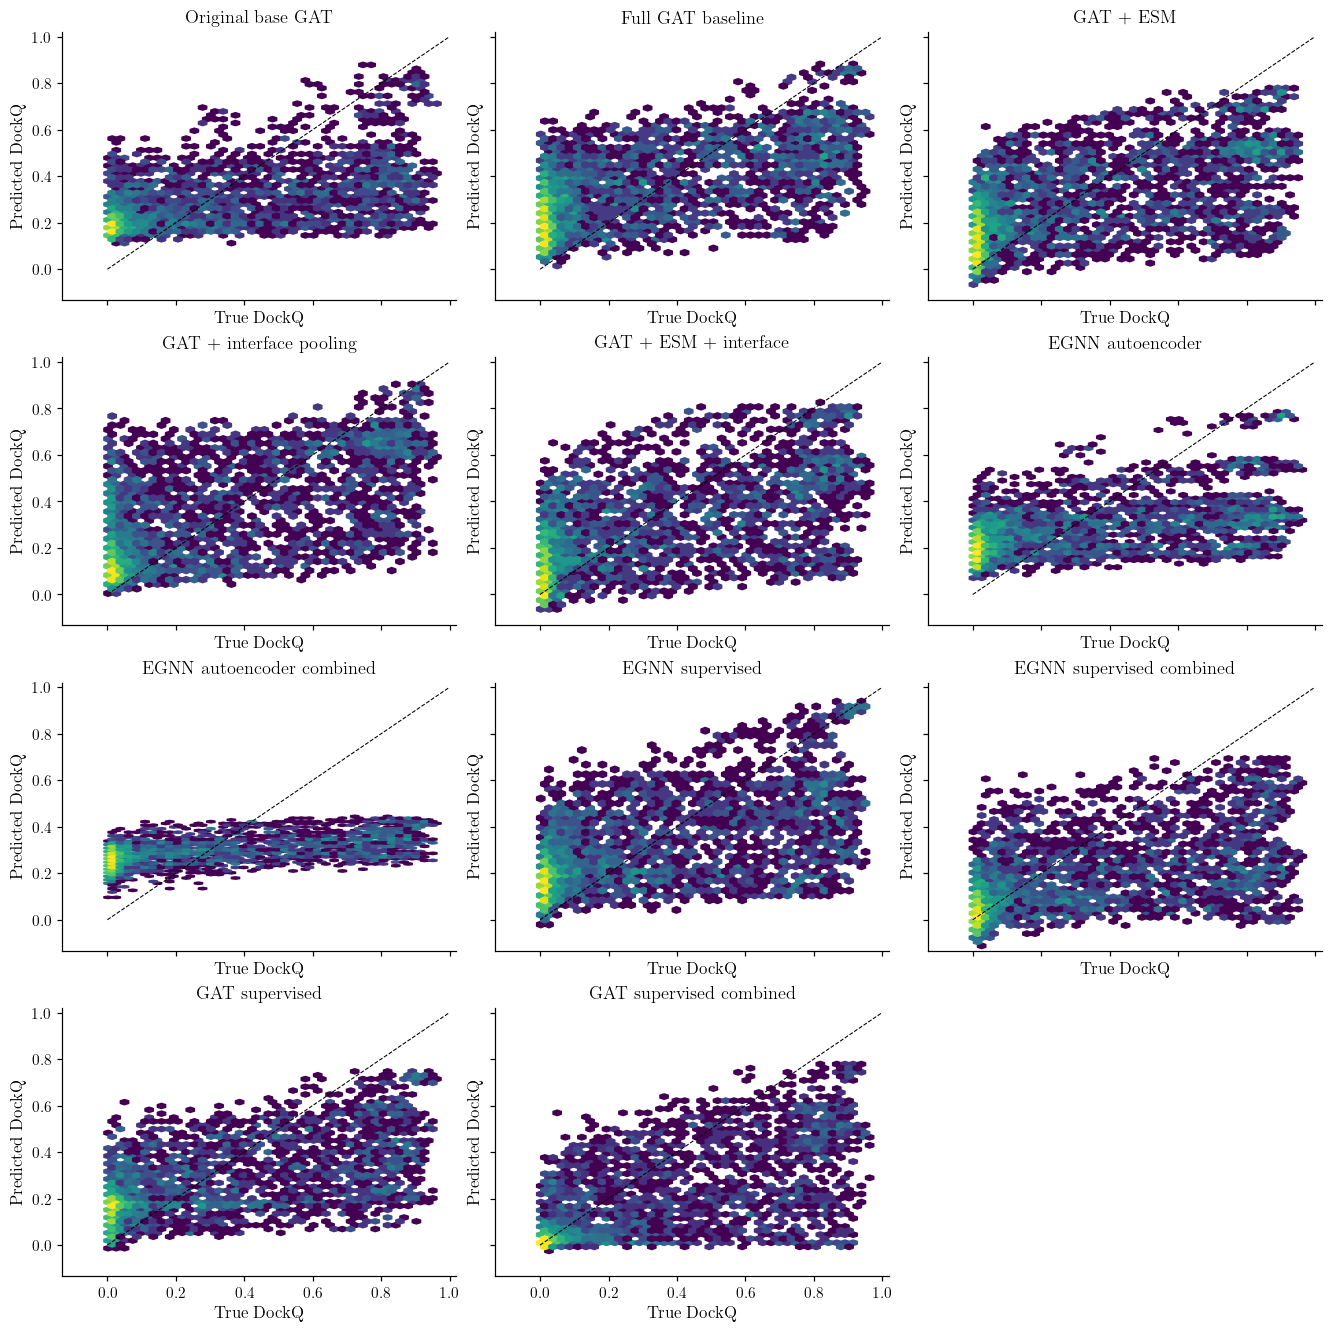

bin,"(-0.001, 0.2]","(0.2, 0.4]","(0.4, 0.6]","(0.6, 0.8]","(0.8, 1.0]"
config,,,,,
seed_replicate_base,0.172,-0.001,-0.172,-0.343,-0.431
baseline,0.204,0.064,-0.080,-0.248,-0.326
gat_none_all_esm1,0.138,0.016,-0.133,-0.310,-0.398
gat_none_interface_esm0,0.167,0.041,-0.085,-0.225,-0.296
gat_none_interface_esm1,0.121,0.012,-0.127,-0.301,-0.385
egnn_ae_baseline,0.174,-0.005,-0.183,-0.367,-0.466
egnn_ae_combined,0.211,-0.001,-0.187,-0.384,-0.515
egnn_supervised_baseline,0.162,0.031,-0.120,-0.285,-0.361
egnn_supervised_combined,0.044,-0.105,-0.259,-0.434,-0.534


In [6]:
lo=min(0,min(f.predicted_target.min() for f in predictions.values()))-.02
hi=max(1,max(f.predicted_target.max() for f in predictions.values()))+.02
fig,axes=plt.subplots(4,3,figsize=(12,12),sharex=True,sharey=True,constrained_layout=True)
for ax,c in zip(axes.flat,ORDER):
 f=predictions[c];ax.hexbin(f.true_target,f.predicted_target,gridsize=40,bins='log',mincnt=1,cmap='viridis',rasterized=True)
 ax.plot([0,1],[0,1],'k--',lw=.7)
 ax.set(title=LABELS[c],xlabel='True DockQ',ylabel='Predicted DockQ',xlim=(lo,hi),ylim=(lo,hi))
for ax in list(axes.flat)[len(ORDER):]:ax.set_visible(False)
save(fig,'observed_predicted')
bins=[]
for c,f in predictions.items():
 for interval,g in f.groupby(pd.cut(f.true_target,np.linspace(0,1,6),include_lowest=True),observed=True):
  bins.append(dict(config=c,bin=str(interval),n=len(g),true_mean=g.true_target.mean(),predicted_mean=g.predicted_target.mean(),bias=(g.predicted_target-g.true_target).mean()))
bins=pd.DataFrame(bins);export(bins,'true_dockq_bins')
display(bins.pivot(index='config',columns='bin',values='bias').reindex(ORDER).round(3))

## Candidate selection and per-target ranking

Top-k quality is the best true DockQ among the top predicted candidates. The random line is only a **single-candidate** reference, not the expected best of k random candidates. Inspect ranking and top-k selection alongside MSE; a good score on one does not guarantee a good score on the other.

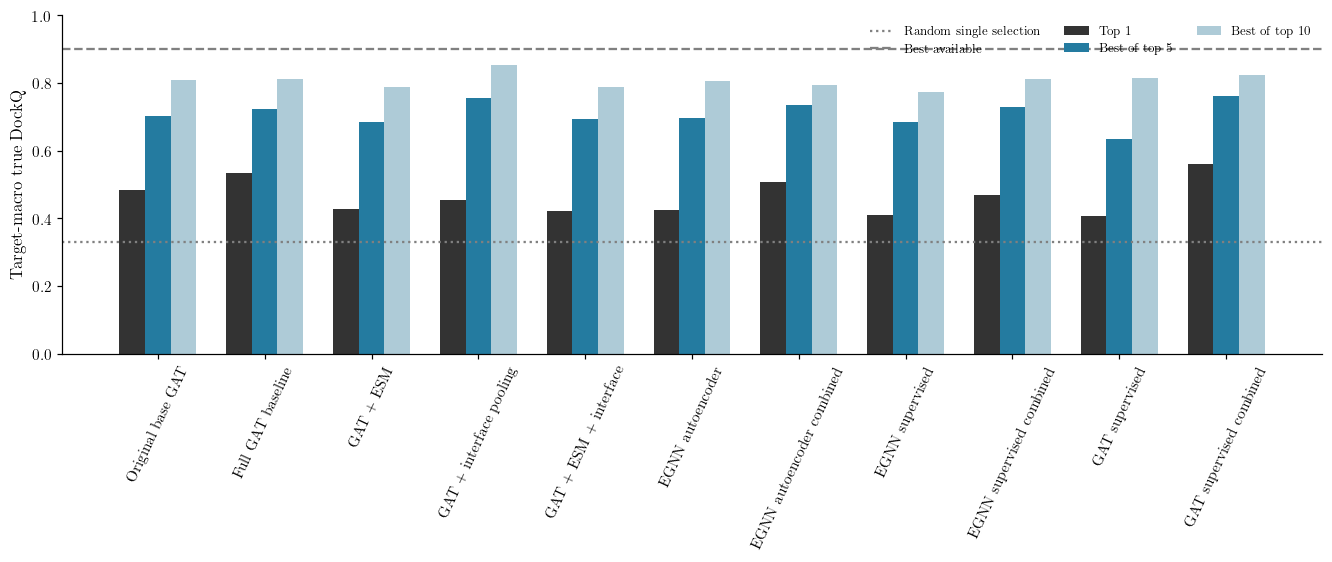

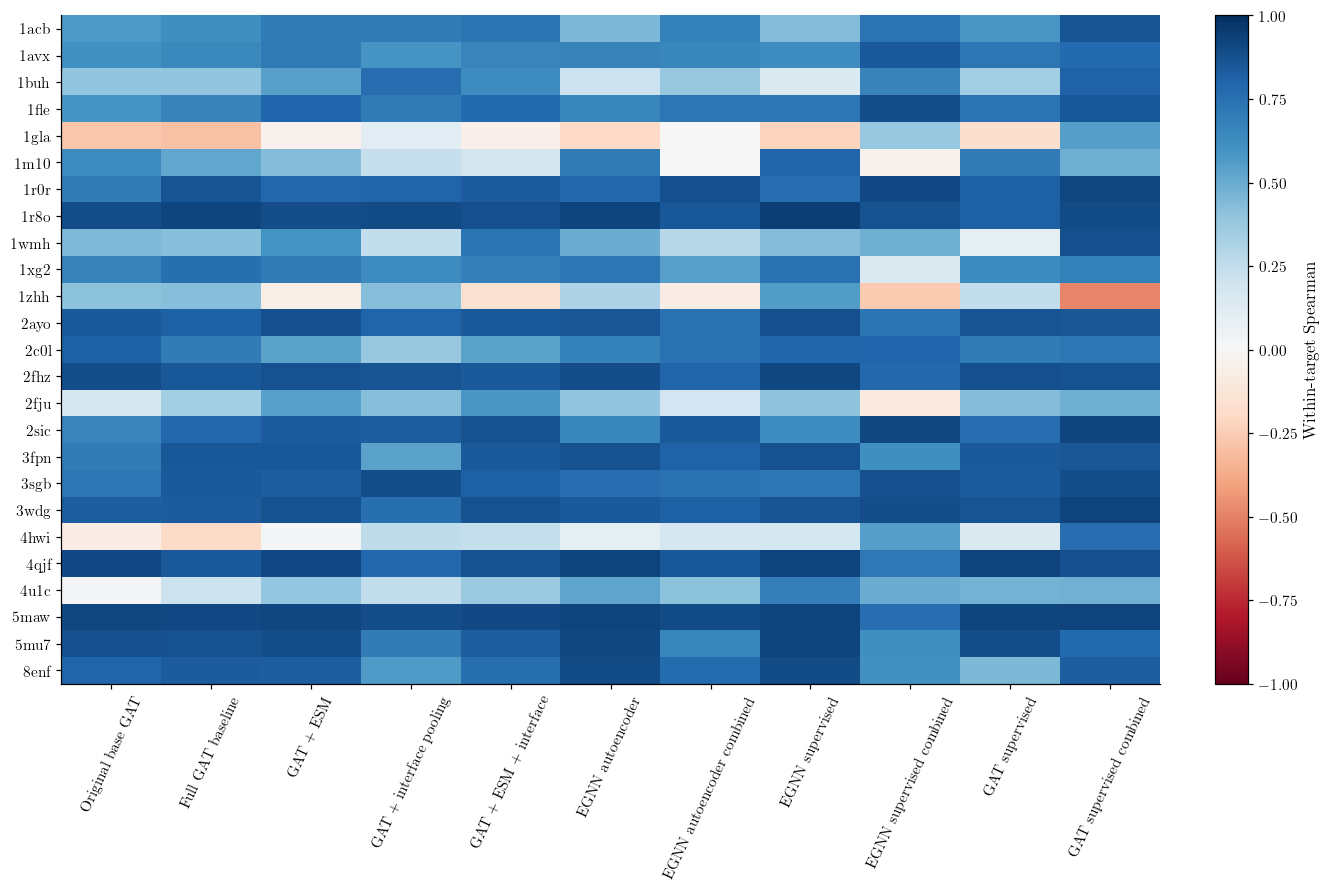

In [7]:
fig,ax=plt.subplots(figsize=(12,5),constrained_layout=True)
x=np.arange(len(ORDER)); width=.24
for j,(key,label,color) in enumerate([('top1','Top 1','#333333'),('top5','Best of top 5','#247ba0'),('top10','Best of top 10','#aecbd7')]):
 ax.bar(x+(j-1)*width,metrics.loc[ORDER,key],width,label=label,color=color)
ax.axhline(metrics.random.iloc[0],color='0.5',ls=':',label='Random single selection')
ax.axhline(metrics.oracle.iloc[0],color='0.5',ls='--',label='Best available')
ax.set(xticks=x,xticklabels=[LABELS[c] for c in ORDER],ylabel='Target-macro true DockQ',ylim=(0,1))
ax.tick_params(axis='x',rotation=65);ax.legend(fontsize=8,ncol=3);save(fig,'top_k_selection')
ranking=per_target.pivot(index='target',columns='config',values='spearman')[ORDER]
fig,ax=plt.subplots(figsize=(12,8),constrained_layout=True)
im=ax.imshow(ranking,vmin=-1,vmax=1,cmap='RdBu',aspect='auto')
ax.set(xticks=range(len(ORDER)),xticklabels=[LABELS[c] for c in ORDER],yticks=range(len(ranking)),yticklabels=ranking.index)
ax.tick_params(axis='x',rotation=65);fig.colorbar(im,ax=ax,label='Within-target Spearman');save(fig,'target_ranking_heatmap')
export(ranking.reset_index(),'target_spearman')

## Controlled GAT feature contrasts

The four autoencoder GAT configurations form a 2×2 comparison of ESM and interface pooling. The contrasts below average over the other factor; the interaction is the difference of differences. They are descriptive within this seed. The full baseline versus original base also changes degree and Voronoi inputs together, so it cannot isolate Voronoi alone.

In [8]:
gat=['baseline','gat_none_all_esm1','gat_none_interface_esm0','gat_none_interface_esm1']
contrasts=[]
for metric in ['macro_mse','macro_spearman','top1']:
 a,b,c,d=metrics.loc[gat,metric].to_numpy()
 contrasts.append(dict(metric=metric,ESM_average_change=((b-a)+(d-c))/2,
  interface_average_change=((c-a)+(d-b))/2,interaction=d-c-b+a))
contrasts=pd.DataFrame(contrasts);display(contrasts.round(5));export(contrasts,'gat_factorial_contrasts')
print('Changes are in the original metric direction: negative is better for MSE; positive for ranking/selection.')

,metric,ESM_average_change,interface_average_change,interaction
0,macro_mse,0.00498,0.00160,-0.00009
1,macro_spearman,0.03717,-0.01060,0.01107
2,top1,-0.07016,-0.04456,0.07544


Changes are in the original metric direction: negative is better for MSE; positive for ranking/selection.


## Target prediction panels

Change `PANEL_RUN` to inspect any configuration. The default is the full-feature baseline, chosen as the prespecified control rather than from test performance. Each panel shows all candidates and its within-target rank correlation.

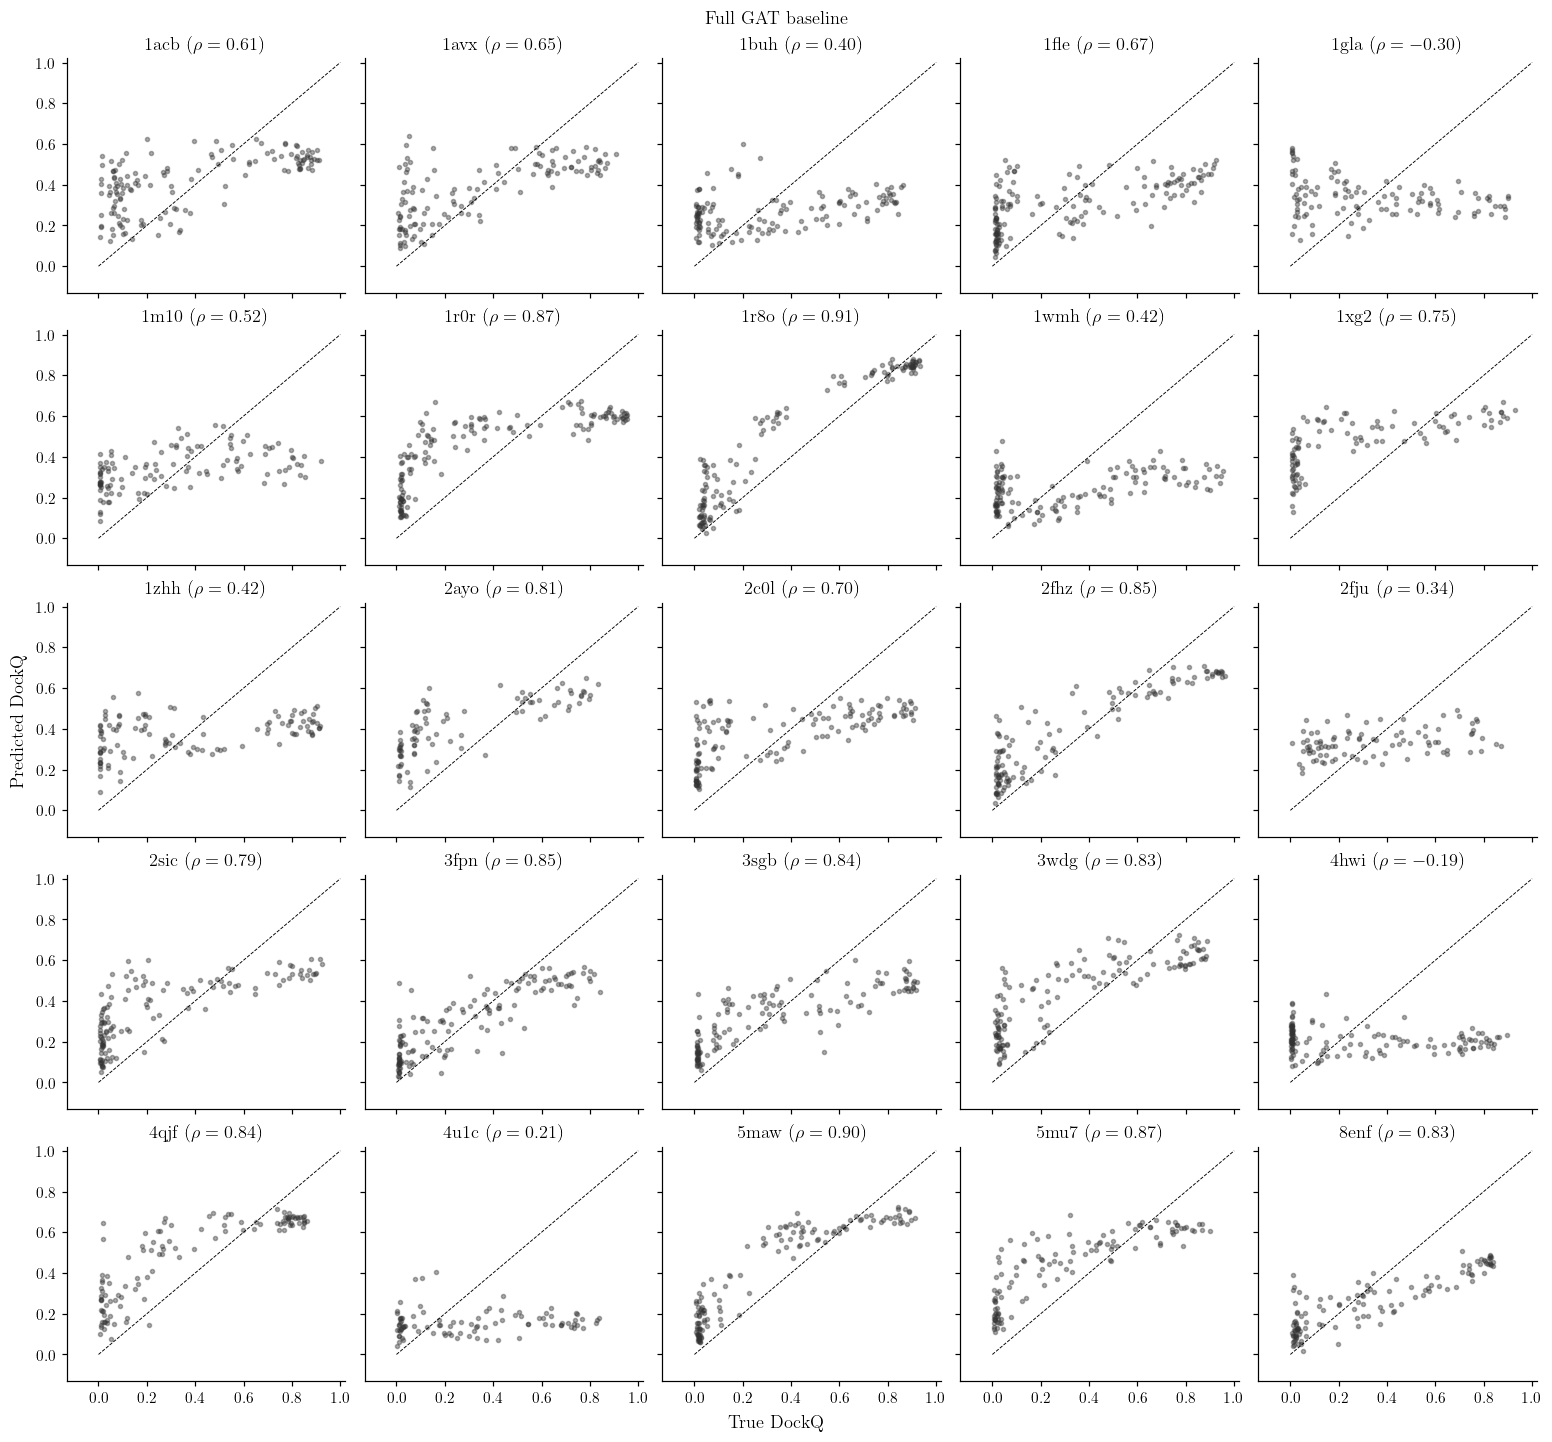

In [9]:
PANEL_RUN='baseline'
f=predictions[PANEL_RUN];targets=sorted(f.target_id.unique())
fig,axes=plt.subplots(int(np.ceil(len(targets)/5)),5,figsize=(14,2.6*int(np.ceil(len(targets)/5))),sharex=True,sharey=True,constrained_layout=True)
for ax,t in zip(axes.flat,targets):
 g=f[f.target_id==t];rho=corr(g.true_target,g.predicted_target,True)
 ax.scatter(g.true_target,g.predicted_target,s=7,alpha=.4,color=COLORS[PANEL_RUN],rasterized=True)
 ax.plot([0,1],[0,1],'k--',lw=.6)
 ax.set(title=t+rf' ($\rho={rho:.2f}$)',xlim=(lo,hi),ylim=(lo,hi))
for ax in list(axes.flat)[len(targets):]:ax.set_visible(False)
fig.supxlabel('True DockQ');fig.supylabel('Predicted DockQ');fig.suptitle(LABELS[PANEL_RUN])
save(fig,'target_predictions_'+PANEL_RUN)

## Readout and limits

This notebook reports all configurations without choosing a final model from the test set. Differences should be checked across seeds before the next model-selection decision. Bootstrap intervals do not account for unobserved training seeds or alternative train/test splits.

In [10]:
base=metrics.loc['baseline']; old=metrics.loc['seed_replicate_base']
best_mse=metrics.macro_mse.idxmin();best_rank=metrics.macro_spearman.idxmax();best_top=metrics.top1.idxmax()
text=f"""**Quick-run observations (seed 7):**

- Original base / full GAT target-macro MSE: **{old.macro_mse:.4f} / {base.macro_mse:.4f}**.
- Lowest observed macro MSE: **{LABELS[best_mse]} ({metrics.loc[best_mse,'macro_mse']:.4f})**.
- Highest within-target Spearman: **{LABELS[best_rank]} ({metrics.loc[best_rank,'macro_spearman']:.3f})**.
- Highest top-1 true DockQ: **{LABELS[best_top]} ({metrics.loc[best_top,'top1']:.3f})**.
- All runs share **{len(reference):,} test graphs and {reference.target_id.nunique()} targets**.

These are observations on this test cohort, not evidence that the best-looking configuration will win across seeds. The fixed loss objective and subset cohort differ from the earlier seed-replicate experiment.
"""
display(Markdown(text));(OUT/'readout.md').write_text(text)
print('Exported all tables and figures to',OUT)

**Quick-run observations (seed 7):**

- Original base / full GAT target-macro MSE: **0.0698 / 0.0626**.
- Lowest observed macro MSE: **Full GAT baseline (0.0626)**.
- Highest within-target Spearman: **GAT supervised combined (0.735)**.
- Highest top-1 true DockQ: **GAT supervised combined (0.560)**.
- All runs share **3,044 test graphs and 25 targets**.

These are observations on this test cohort, not evidence that the best-looking configuration will win across seeds. The fixed loss objective and subset cohort differ from the earlier seed-replicate experiment.


Exported all tables and figures to /scratch/PPI-graph_autoencoder/gate_run/model_extensions_quick_analysis
